In [5]:
!pip install torch torchvision opencv-python scipy scikit-image tqdm

In [6]:
!nvidia-smi

Wed Dec 24 19:39:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             49W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!wget --no-check-certificate https://datasets.simula.no/downloads/kvasir-seg.zip

# Unzip
!unzip -q kvasir-seg.zip

--2025-12-24 19:38:28--  https://datasets.simula.no/downloads/kvasir-seg.zip
Resolving datasets.simula.no (datasets.simula.no)... 128.39.36.14
Connecting to datasets.simula.no (datasets.simula.no)|128.39.36.14|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 46227172 (44M) [application/zip]
Saving to: ‘kvasir-seg.zip’

kvasir-seg.zip      100%[===================>]  44.08M  2.02MB/s    in 25s     

2025-12-24 19:38:54 (1.75 MB/s) - ‘kvasir-seg.zip’ saved [46227172/46227172]



In [4]:
!ls


Kvasir-SEG  kvasir-seg.zip  sample_data


In [7]:
!ls Kvasir-SEG

images	kavsir_bboxes.json  masks


In [8]:
import glob
import os

image_paths = sorted(glob.glob("Kvasir-SEG/images/*.jpg"))
mask_paths  = sorted(glob.glob("Kvasir-SEG/masks/*.jpg"))

print(len(image_paths), len(mask_paths))

1000 1000


In [9]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_transform(mode='train', sign='label', transform=None):
    if transform is None:
        if mode == 'train' and sign == 'label':
            transform = A.Compose([
                A.Resize(384, 384),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
                A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.5),
                A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
                A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
                A.GaussianBlur(blur_limit=(3,3), p=0.1),
                ToTensorV2()
            ])
        elif mode == 'train' and sign == 'unlabel':
            transform = A.Compose([
                A.Resize(384, 384),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
                ToTensorV2()
            ])
        elif mode == 'valid' or mode == 'test':
            transform = A.Compose([
                A.Resize(384, 384),
                ToTensorV2()
            ])
    return transform

# Örnek kullanım
train_label_transform = get_transform(mode='train', sign='label')
train_unlabel_transform = get_transform(mode='train', sign='unlabel')
test_transform = get_transform(mode='test')


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-3278679499.py:14: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),


In [10]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class PolypDataset(Dataset):
    def __init__(self, img_paths, mask_paths=None, transforms=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transforms

        if self.mask_paths is not None:
            assert len(self.img_paths) == len(self.mask_paths), \
                "Image and mask list lengths must match"

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # ---- image ----
        image = cv2.imread(self.img_paths[idx])
        if image is None:
            raise RuntimeError(f"Image not found: {self.img_paths[idx]}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # ---- mask ----
        mask = None
        if self.mask_paths is not None:
            mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
            if mask is None:
                raise RuntimeError(f"Mask not found: {self.mask_paths[idx]}")

        # ---- transforms ----
        if self.transform:
            if mask is not None:
                augmented = self.transform(image=image, mask=mask)
                image = augmented["image"]
                mask = augmented["mask"]
            else:
                augmented = self.transform(image=image)
                image = augmented["image"]

        # ---- mask postprocess ----
        if mask is not None:
            # Convert to tensor if still numpy array
            if isinstance(mask, np.ndarray):
                mask = torch.from_numpy(mask).float()
            else:
                mask = mask.float()
            mask = (mask / 255.0 > 0.5).float().unsqueeze(0)
        else:
            # Return empty tensor for unlabeled data
            mask = torch.tensor([], dtype=torch.float32)

        return {"image": image, "label": mask}

In [11]:
from sklearn.model_selection import train_test_split

# ORİJİNAL MAKALE: 600 Train, 200 Valid, 200 Test
# Toplam 1000 görüntü -> %60 train, %20 valid, %20 test

# İlk olarak train+valid (%80) ve test (%20) ayır
train_val_imgs, test_imgs, train_val_masks, test_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,  # 200 test
    random_state=42
)

# Sonra train (%75 of train_val = 600) ve valid (%25 of train_val = 200) ayır
train_imgs, valid_imgs, train_masks, valid_masks = train_test_split(
    train_val_imgs,
    train_val_masks,
    test_size=0.25,  # 200 validation
    random_state=42
)

print(f"Train: {len(train_imgs)}, Valid: {len(valid_imgs)}, Test: {len(test_imgs)}")

Train: 600, Valid: 200, Test: 200


In [12]:
# ORİJİNAL MAKALE: 120L + 480U (yani %20 labeled, %80 unlabeled)
train_l_imgs, train_u_imgs, train_l_masks, train_u_masks = train_test_split(
    train_imgs,
    train_masks,
    test_size=0.8,  # %80 unlabeled
    random_state=42
)

print(f"Labeled: {len(train_l_imgs)}, Unlabeled: {len(train_u_imgs)}")

Labeled: 120, Unlabeled: 480


In [13]:
print("=" * 50)
print("DATASET SPLIT (Orijinal Makale ile Uyumlu)")
print("=" * 50)
print(f"Train Labelled  : {len(train_l_imgs)} (Hedef: ~120)")
print(f"Train Unlabelled: {len(train_u_imgs)} (Hedef: ~480)")
print(f"Validation      : {len(valid_imgs)} (Hedef: 200)")
print(f"Test            : {len(test_imgs)} (Hedef: 200)")
print("=" * 50)

DATASET SPLIT (Orijinal Makale ile Uyumlu)
Train Labelled  : 120 (Hedef: ~120)
Train Unlabelled: 480 (Hedef: ~480)
Validation      : 200 (Hedef: 200)
Test            : 200 (Hedef: 200)


In [14]:
# Unlabelled dataset - minimal augmentasyon
train_Udataset = PolypDataset(
    img_paths=train_u_imgs,
    mask_paths=None,
    transforms=train_unlabel_transform
)

# Labelled dataset - tam augmentasyonlu
train_Ldataset = PolypDataset(
    img_paths=train_l_imgs,
    mask_paths=train_l_masks,
    transforms=train_label_transform
)

# Validation dataset - augmentasyonsuz
valid_dataset = PolypDataset(
    img_paths=valid_imgs,
    mask_paths=valid_masks,
    transforms=test_transform,
)

# Test dataset - augmentasyonsuz
test_dataset = PolypDataset(
    img_paths=test_imgs,
    mask_paths=test_masks,
    transforms=test_transform,
)

In [15]:
from torch.utils.data import DataLoader

unlabeled_train_loader = DataLoader(train_Udataset, batch_size=4, shuffle=True)
labeled_train_loader = DataLoader(train_Ldataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

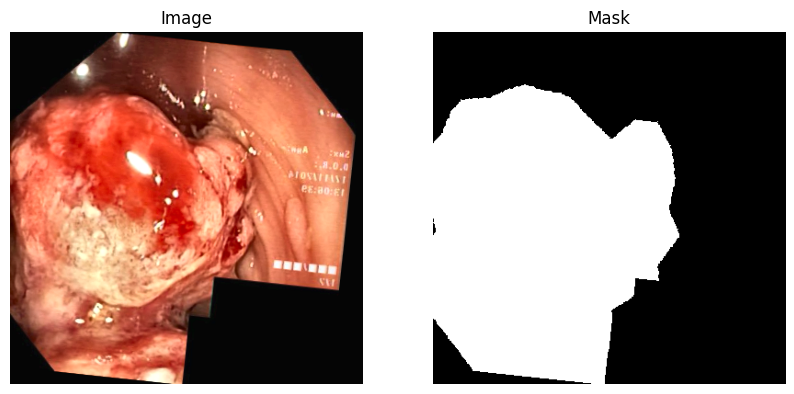

In [16]:
import matplotlib.pyplot as plt
import torch # Ensure torch is imported

# Get the next batch, which is a dictionary from PolypDataset
batch_data = next(iter(labeled_train_loader))

# Extract the image and mask tensors from the dictionary
images_batch = batch_data['image'] # This will be the batch of image tensors
masks_batch = batch_data['label']  # This will be the batch of mask tensors

img, mask = images_batch[0], masks_batch[0] # Take the first image and mask from the batch

# Ensure tensors are on CPU and convert to numpy for matplotlib
# Added isinstance check for robustness, though img and mask should be torch.Tensor here.
if isinstance(img, torch.Tensor):
    img_display = img.cpu().numpy()
else:
    raise TypeError(f"Expected a torch.Tensor for img, but got {type(img)}")

if isinstance(mask, torch.Tensor):
    mask_display = mask.squeeze().cpu().numpy()
else:
    raise TypeError(f"Expected a torch.Tensor for mask, but got {type(mask)}")


# Transpose the image data from (C, H, W) to (H, W, C) for matplotlib
# Check image dimensions before transposing, assuming RGB (C, H, W) or grayscale (H, W)
if img_display.ndim == 3 and img_display.shape[0] == 3:
    img_display = img_display.transpose(1, 2, 0)
elif img_display.ndim == 2:
    pass # No transpose needed for 2D (grayscale) images
else:
    print(f"Warning: Unexpected image dimensions for img_display: {img_display.shape}")

plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)
plt.title(f"Image") # Removed empty parenthesis
plt.imshow(img_display)
plt.axis("off") # Added for consistency

plt.subplot(1,2,2)
plt.title(f"Mask")
plt.imshow(mask_display, cmap='gray')
plt.axis("off")

plt.show()

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms.functional as TF
resnet34 = models.resnet34(pretrained=True)

class EncoderBlock(nn.Module):
  def __init__(self):
    super().__init__()
    resnet = resnet34

    self.enc1_conv = resnet.conv1
    self.enc1_bn = resnet.bn1
    self.enc1_relu = resnet.relu
    self.enc1_maxpool = resnet.maxpool

    self.enc2 = resnet.layer1
    self.enc3 = resnet.layer2
    self.enc4 = resnet.layer3
    self.enc5 = resnet.layer4

  def forward(self, x):
    e1 = self.enc1_relu(self.enc1_bn(self.enc1_conv(x)))
    e1_maxpool = self.enc1_maxpool(e1)
    e2 = self.enc2(e1_maxpool)
    e3 = self.enc3(e2)
    e4 = self.enc4(e3)
    e5 = self.enc5(e4)

    return e1, e2, e3, e4, e5


class DecoderBlock(nn.Module):
  def __init__(self, in_channels, out_channels, isInpainting=False):
    super().__init__()

    self.conv1 = nn.Sequential(nn.Conv2d(in_channels=in_channels, out_channels=in_channels//4, kernel_size=3, stride=1, padding=1),
                               nn.BatchNorm2d(in_channels//4),
                               nn.ReLU(inplace=True)
                               )
    self.conv2 = nn.Sequential(nn.Conv2d(in_channels=in_channels//4, out_channels=out_channels, kernel_size=3, stride=1, padding=1),
                               nn.BatchNorm2d(out_channels),
                               nn.ReLU(inplace=True)
                               )

    if isInpainting:
      self.upsample = nn.Sequential(nn.ConvTranspose2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
                                    nn.BatchNorm2d(out_channels),
                                    nn.ReLU(inplace=True))
    else:
      self.upsample = nn.Upsample(scale_factor=2, mode='bilinear')


  def forward(self, x):
    return self.upsample(self.conv2(self.conv1(x)))


class GFF(nn.Module):
  def __init__(self, in_channels):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels=2*in_channels, out_channels=in_channels, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(in_channels=2*in_channels, out_channels=in_channels, kernel_size=3, stride=1, padding=1)
    self.conv3 = nn.Conv2d(in_channels=2*in_channels, out_channels=in_channels, kernel_size=3, stride=1, padding=1)

    self.relu = nn.ReLU(inplace=True)

    self.sigmoid1 = nn.Sigmoid()
    self.sigmoid2 = nn.Sigmoid()

    nn.init.orthogonal_(self.conv1.weight)
    nn.init.orthogonal_(self.conv2.weight)
    nn.init.orthogonal_(self.conv3.weight)

    nn.init.constant_(self.conv1.bias, 0.0)
    nn.init.constant_(self.conv2.bias, 0.0)
    nn.init.constant_(self.conv3.bias, 0.0)

  def forward(self, sege, inpe):
    x = torch.cat([sege, inpe], dim=1)
    reset = self.sigmoid1(self.conv1(x))
    select = self.sigmoid2(self.conv2(x))

    re_sege = self.relu(self.conv3(torch.cat([sege, reset*inpe], dim=1)))

    return (re_sege*select) + ((1-select) * sege)

class SideBlock(nn.Module):
  def __init__(self, in_channels, out_channels=1, haveSigmoid=True, Divider = 4):
    super().__init__()
    self.haveSigmoid = haveSigmoid
    self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=in_channels//Divider, kernel_size=3, stride=1, padding=1)
    self.dropout = nn.Dropout2d(0.1)
    self.conv2 = nn.Conv2d(in_channels=in_channels//Divider, out_channels=out_channels, kernel_size=1, stride=1, padding=0)

    if haveSigmoid:
      self.Sigmoid = nn.Sigmoid()

  def forward(self, x):
    if self.haveSigmoid:
      return self.Sigmoid(self.conv2(self.dropout(self.conv1(x))))
    else:
      return self.conv2(self.dropout(self.conv1(x)))




/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 238MB/s]


In [18]:
class MyModel(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()

    self.Encoder = EncoderBlock()

    self.seg_decoder1 = DecoderBlock(64 + 64, 64)
    self.seg_decoder2 = DecoderBlock(128 + 64, 64)
    self.seg_decoder3 = DecoderBlock(256 + 128, 128)
    self.seg_decoder4 = DecoderBlock(512 + 256, 256)
    self.seg_decoder5 = DecoderBlock(512, 512)

    self.seg_outconv = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1),
        nn.Dropout(0.1),
        nn.Conv2d(in_channels=32, out_channels=1, kernel_size=1, stride=1, padding=0)
    )

    self.gff1 = GFF(64)
    self.gff2 = GFF(64)
    self.gff3 = GFF(128)
    self.gff4 = GFF(256)
    self.gff5 = GFF(512)

    # Orijinal projede sigmoid model içinde - haveSigmoid=True (default)
    self.seg_sideout1 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.Dropout(0.1),
        nn.Conv2d(in_channels=32, out_channels=1, kernel_size=1, stride=1, padding=0)
    )
    self.seg_sideout2 = SideBlock(in_channels=64, haveSigmoid=True)  # Sigmoid AÇIK
    self.seg_sideout3 = SideBlock(in_channels=128, haveSigmoid=True)  # Sigmoid AÇIK
    self.seg_sideout4 = SideBlock(in_channels=256, haveSigmoid=True)  # Sigmoid AÇIK
    self.seg_sideout5 = SideBlock(in_channels=512, haveSigmoid=True)  # Sigmoid AÇIK

    self.inp_decoder1 = DecoderBlock(64 + 64, 64, isInpainting=True)
    self.inp_decoder2 = DecoderBlock(128 + 64, 64, isInpainting=True)
    self.inp_decoder3 = DecoderBlock(256 + 128, 128, isInpainting=True)
    self.inp_decoder4 = DecoderBlock(512 + 256, 256, isInpainting=True)
    self.inp_decoder5 = DecoderBlock(512, 512, isInpainting=True)

    self.inp_sideout1 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.Dropout(0.1),
        nn.Conv2d(in_channels=32, out_channels=in_channels, kernel_size=1, stride=1, padding=0)
    )
    self.inp_sideout2 = SideBlock(in_channels=64, out_channels=in_channels, haveSigmoid=False)
    self.inp_sideout3 = SideBlock(in_channels=128, out_channels=in_channels, haveSigmoid=False)
    self.inp_sideout4 = SideBlock(in_channels=256, out_channels=in_channels, haveSigmoid=False)
    self.inp_sideout5 = SideBlock(in_channels=512, out_channels=in_channels, haveSigmoid=False)


  def forward(self, x):
    ori = x

    e1, e2, e3, e4, e5 = self.Encoder(x)

    # İlk pass - coarse segmentation
    d5 = self.seg_decoder5(e5)
    d4 = self.seg_decoder4(torch.cat([e4, d5], dim=1))
    d3 = self.seg_decoder3(torch.cat([e3, d4], dim=1))
    d2 = self.seg_decoder2(torch.cat([e2, d3], dim=1))
    d1 = self.seg_decoder1(torch.cat([e1, d2], dim=1))

    mask = self.seg_outconv(d1)
    mask = torch.sigmoid(mask)  # Orijinal projede sigmoid var
    mask_binary = (mask < 0.5).float()
    mask_rbinary = (mask > 0.5).float()

    # Inpainting için maskelenmiş görüntü
    cut_ori = ori * mask_rbinary

    # İkinci pass - GFF ile birleştirilmiş
    e1, e2, e3, e4, e5 = self.Encoder(ori)
    inpe1, inpe2, inpe3, inpe4, inpe5 = self.Encoder(cut_ori)

    ge5 = self.gff5(e5, inpe5)
    ge4 = self.gff4(e4, inpe4)
    ge3 = self.gff3(e3, inpe3)
    ge2 = self.gff2(e2, inpe2)
    ge1 = self.gff1(e1, inpe1)

    d5 = self.seg_decoder5(ge5)
    d4 = self.seg_decoder4(torch.cat([ge4, d5], dim=1))
    d3 = self.seg_decoder3(torch.cat([ge3, d4], dim=1))
    d2 = self.seg_decoder2(torch.cat([ge2, d3], dim=1))
    d1 = self.seg_decoder1(torch.cat([ge1, d2], dim=1))

    # Side outputs - Orijinal projede sigmoid uygulanıyor
    sidemask5 = self.seg_sideout5(d5)  # SideBlock içinde sigmoid var
    sidemask4 = self.seg_sideout4(d4)
    sidemask3 = self.seg_sideout3(d3)
    sidemask2 = self.seg_sideout2(d2)
    sidemask1_logit = self.seg_sideout1(d1)  # Sequential - sigmoid yok
    sidemask1 = torch.sigmoid(sidemask1_logit)  # Manuel sigmoid ekle

    # Inpainting için binary mask
    mask_binary = (sidemask1 > 0.5).float()
    mask_rbinary = (sidemask1 < 0.5).float()

    # Inpainting decoder
    inp_d5 = self.inp_decoder5(ge5)
    inp_d4 = self.inp_decoder4(torch.cat([ge4, inp_d5], dim=1))
    inp_d3 = self.inp_decoder3(torch.cat([ge3, inp_d4], dim=1))
    inp_d2 = self.inp_decoder2(torch.cat([ge2, inp_d3], dim=1))
    inp_d1 = self.inp_decoder1(torch.cat([ge1, inp_d2], dim=1))

    sideinp5 = self.inp_sideout5(inp_d5)
    sideinp4 = self.inp_sideout4(inp_d4)
    sideinp3 = self.inp_sideout3(inp_d3)
    sideinp2 = self.inp_sideout2(inp_d2)
    sideinp1 = self.inp_sideout1(inp_d1)

    inpimg = sideinp1 * mask_binary + ori * mask_rbinary

    # Orijinal projedeki sıra: mask, sidemask2, sidemask3, sidemask4, sidemask5
    # Tüm çıktılar SIGMOID uygulanmış (probability)
    return sidemask1, sidemask2, sidemask3, sidemask4, sidemask5, inpimg, sideinp2, sideinp3, sideinp4, sideinp5

In [19]:
# DÜZELTME: model yerine net değişken adı kullanıldı (variable shadowing önlemek için)
net = MyModel(in_channels=3, out_channels=1)
net.eval()

x = torch.randn(1, 3, 256, 256)

with torch.no_grad():
    outputs = net(x)

for i, out in enumerate(outputs):
    print(f"Output {i}: shape = {out.shape}")

Output 0: shape = torch.Size([1, 1, 256, 256])
Output 1: shape = torch.Size([1, 1, 128, 128])
Output 2: shape = torch.Size([1, 1, 64, 64])
Output 3: shape = torch.Size([1, 1, 32, 32])
Output 4: shape = torch.Size([1, 1, 16, 16])
Output 5: shape = torch.Size([1, 3, 256, 256])
Output 6: shape = torch.Size([1, 3, 128, 128])
Output 7: shape = torch.Size([1, 3, 64, 64])
Output 8: shape = torch.Size([1, 3, 32, 32])
Output 9: shape = torch.Size([1, 3, 16, 16])


In [20]:
net

MyModel(
  (Encoder): EncoderBlock(
    (enc1_conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (enc1_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc1_relu): ReLU(inplace=True)
    (enc1_maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (enc2): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, 

In [21]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"


In [22]:
unlabeled_train_loader = DataLoader(train_Udataset, batch_size=4, shuffle=True)
labeled_train_loader = DataLoader(train_Ldataset, batch_size=4, shuffle=True)

# DÜZELTME: net kullanılıyor (model sınıfı ile karışmasın)
net = net.to(device)

In [23]:
from itertools import cycle

loader = iter(zip(cycle(labeled_train_loader), unlabeled_train_loader))

data_l, data_u = next(loader)

img_l, gt = data_l['image'], data_l['label']
img_u = data_u

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BceDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        bce = F.binary_cross_entropy_with_logits(pred, target)

        smooth = 1e-5
        pred_sigmoid = torch.sigmoid(pred)
        intersection = (pred_sigmoid * target).sum(dim=(2, 3))
        union = pred_sigmoid.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = 1 - (2. * intersection + smooth) / (union + smooth)

        return bce + dice.mean()

# Referanstaki DeepSupSeg fonksiyonu (Etiketli veriler için)
def deep_sup_seg_loss(preds, gt, criterion):
    # Modelin ilk 5 çıktısının segmentasyon maskesi olduğunu varsayar (farklı ölçeklerde)
    # Eğer modelin sadece 1 çıktı veriyorsa burayı düzenlemelisin.
    loss = 0

    # preds[:5] referanstaki gibi 5 ölçekli çıktı varsayımıdır
    for i, pred in enumerate(preds[:5]):
        # Ground Truth'u tahmin boyutuna göre küçült (Deep Supervision mantığı)
        if i > 0: # İlk iterasyonda zaten boyutu aynıdır, sonrakilerde küçültülür
            gt = F.interpolate(gt, scale_factor=0.5, mode='bilinear', align_corners=True)

        loss += criterion(pred, gt)

    return loss

# Referanstaki DeepSupInp fonksiyonu (Etiketiz veriler için - Semi-Supervised kısım)
def deep_sup_inp_loss(preds, img_original, masks):
    # preds[5:] inpainting/reconstruction çıktıları olduğunu varsayar
    inp_preds = preds[5:]

    criterion = nn.L1Loss()
    loss = 0

    img_target = img_original.detach() # Orijinal resmi hedef olarak al

    for i, inp_pred in enumerate(inp_preds):
        mask = masks[i].detach() # Segmentasyon maskesini al (gradyan takibi yok)

        # Sadece maskenin 0.5'ten büyük olduğu (nesne olduğu düşünülen) alanlarda loss hesapla
        # Bu, modelin "sadece bu bölgeyi doğru tamamla/yeniden oluştur" demesidir.
        select_pred = torch.masked_select(inp_pred, mask > 0.5)
        select_target = torch.masked_select(img_target, mask > 0.5)

        if select_pred.numel() > 0: # Eğer maske boş değilse loss ekle
            loss += criterion(select_pred, select_target)

        # Bir sonraki ölçek için hedef resmi küçült
        img_target = F.interpolate(img_target, scale_factor=0.5, mode='bilinear', align_corners=True)

    return loss

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from types import SimpleNamespace
from tqdm import tqdm
from itertools import cycle
import os

# ============================================================
# 1. GEREKLİ CLASS VE FONKSİYONLAR - ORİJİNAL PROJE İLE UYUMLU
# ============================================================

# Orijinal projeden: BCE Loss (probability bekliyor, logit değil!)
class BCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(BCELoss, self).__init__()
        self.bceloss = nn.BCELoss(weight, reduction='mean' if size_average else 'sum')

    def forward(self, pred, target):
        sizep = pred.size(0)
        sizet = target.size(0)
        pred_flat = pred.view(sizep, -1)
        target_flat = target.view(sizet, -1)
        loss = self.bceloss(pred_flat, target_flat)
        return loss

# Orijinal projeden: Dice Loss
class DiceLoss(nn.Module):
    def __init__(self, size_average=True):
        super(DiceLoss, self).__init__()

    def forward(self, pred, target):
        smooth = 1
        size = target.size(0)
        pred_flat = pred.view(size, -1)
        target_flat = target.view(size, -1)
        intersection = pred_flat * target_flat
        dice_score = (2 * intersection.sum(1) + smooth) / (pred_flat.sum(1) + target_flat.sum(1) + smooth)
        dice_loss = 1 - dice_score.sum() / size
        return dice_loss

# Orijinal projeden: BCE + Dice Loss (probability bekliyor!)
class BceDiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(BceDiceLoss, self).__init__()
        self.bce = BCELoss(weight, size_average)
        self.dice = DiceLoss(size_average)

    def forward(self, pred, target):
        bceloss = self.bce(pred, target)
        diceloss = self.dice(pred, target)
        return bceloss + diceloss


# --- Referans Koddan Gelen Fonksiyonlar ---

def DeepSupSeg(pred, gt):
    d0, d1, d2, d3, d4 = pred[:5]
    criterion = BceDiceLoss().cuda()
    gt_curr = gt.clone()

    loss0 = criterion(d0, gt_curr)
    gt_curr = F.interpolate(gt_curr, scale_factor=0.5, mode='bilinear', align_corners=True)
    loss1 = criterion(d1, gt_curr)
    gt_curr = F.interpolate(gt_curr, scale_factor=0.5, mode='bilinear', align_corners=True)
    loss2 = criterion(d2, gt_curr)
    gt_curr = F.interpolate(gt_curr, scale_factor=0.5, mode='bilinear', align_corners=True)
    loss3 = criterion(d3, gt_curr)
    gt_curr = F.interpolate(gt_curr, scale_factor=0.5, mode='bilinear', align_corners=True)
    loss4 = criterion(d4, gt_curr)

    return loss0 + loss1 + loss2 + loss3 + loss4

def DeepSupInp(pred, gt, mask):
    criterion = nn.L1Loss()
    loss = 0
    curr_gt = gt.clone()

    for i in range(len(pred)):
        if i >= len(mask): break
        curr_mask = mask[i]
        select_pred = torch.masked_select(pred[i], curr_mask > 0.5)
        select_target = torch.masked_select(curr_gt, curr_mask > 0.5)

        if select_pred.numel() > 0:
            loss += criterion(select_pred, select_target)

        curr_gt = F.interpolate(curr_gt, scale_factor=0.5, mode='bilinear', align_corners=True)
    return loss


def quick_evaluate(model, dataloader, device):
    """Validation için hızlı Dice/F1 hesaplama"""
    model.eval()
    total_dice = 0
    num_samples = 0

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, dict):
                img, gt = batch['image'], batch['label']
            else:
                img, gt = batch

            img = img.to(device).float() / 255.0
            gt = gt.to(device).float()

            output = model(img)
            pred = output[0]
            pred_bin = (pred >= 0.5).float()
            gt_bin = (gt >= 0.5).float()

            for i in range(img.size(0)):
                p = pred_bin[i]
                g = gt_bin[i]

                TP = (p * g).sum()
                FP = (p * (1 - g)).sum()
                FN = ((1 - p) * g).sum()

                eps = 1e-7
                dice = (2 * TP) / (2 * TP + FP + FN + eps)
                total_dice += dice.item()
                num_samples += 1

    return total_dice / num_samples


def lr_poly(base_lr, iter, max_iter, power):
    return base_lr * ((1-float(iter)/max_iter)**power)

def adjust_lr_rate(optimizer, iter, max_iter, args):
    lr = lr_poly(args.lr, iter, max_iter, args.power)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    return lr

In [26]:
from google.colab import drive
drive.mount('/content/drive')
checkpoint_dir = "/content/drive/MyDrive/models2"
net.load_state_dict(torch.load(os.path.join(checkpoint_dir, "best_model.pth")))


Mounted at /content/drive


<All keys matched successfully>

TEST SET EVALUATION


Evaluating on Test Set: 100%|██████████| 200/200 [00:07<00:00, 25.68it/s]



RESULTS
Recall              : 0.8883
Specificity         : 0.9801
Precision           : 0.8795
F1                  : 0.8643
F2                  : 0.8715
Accuracy            : 0.9576
IoU_Polyp           : 0.7861
IoU_Background      : 0.9460
IoU_Mean (mIoU)     : 0.8661
Dice                : 0.8643

📊 Sample Predictions:


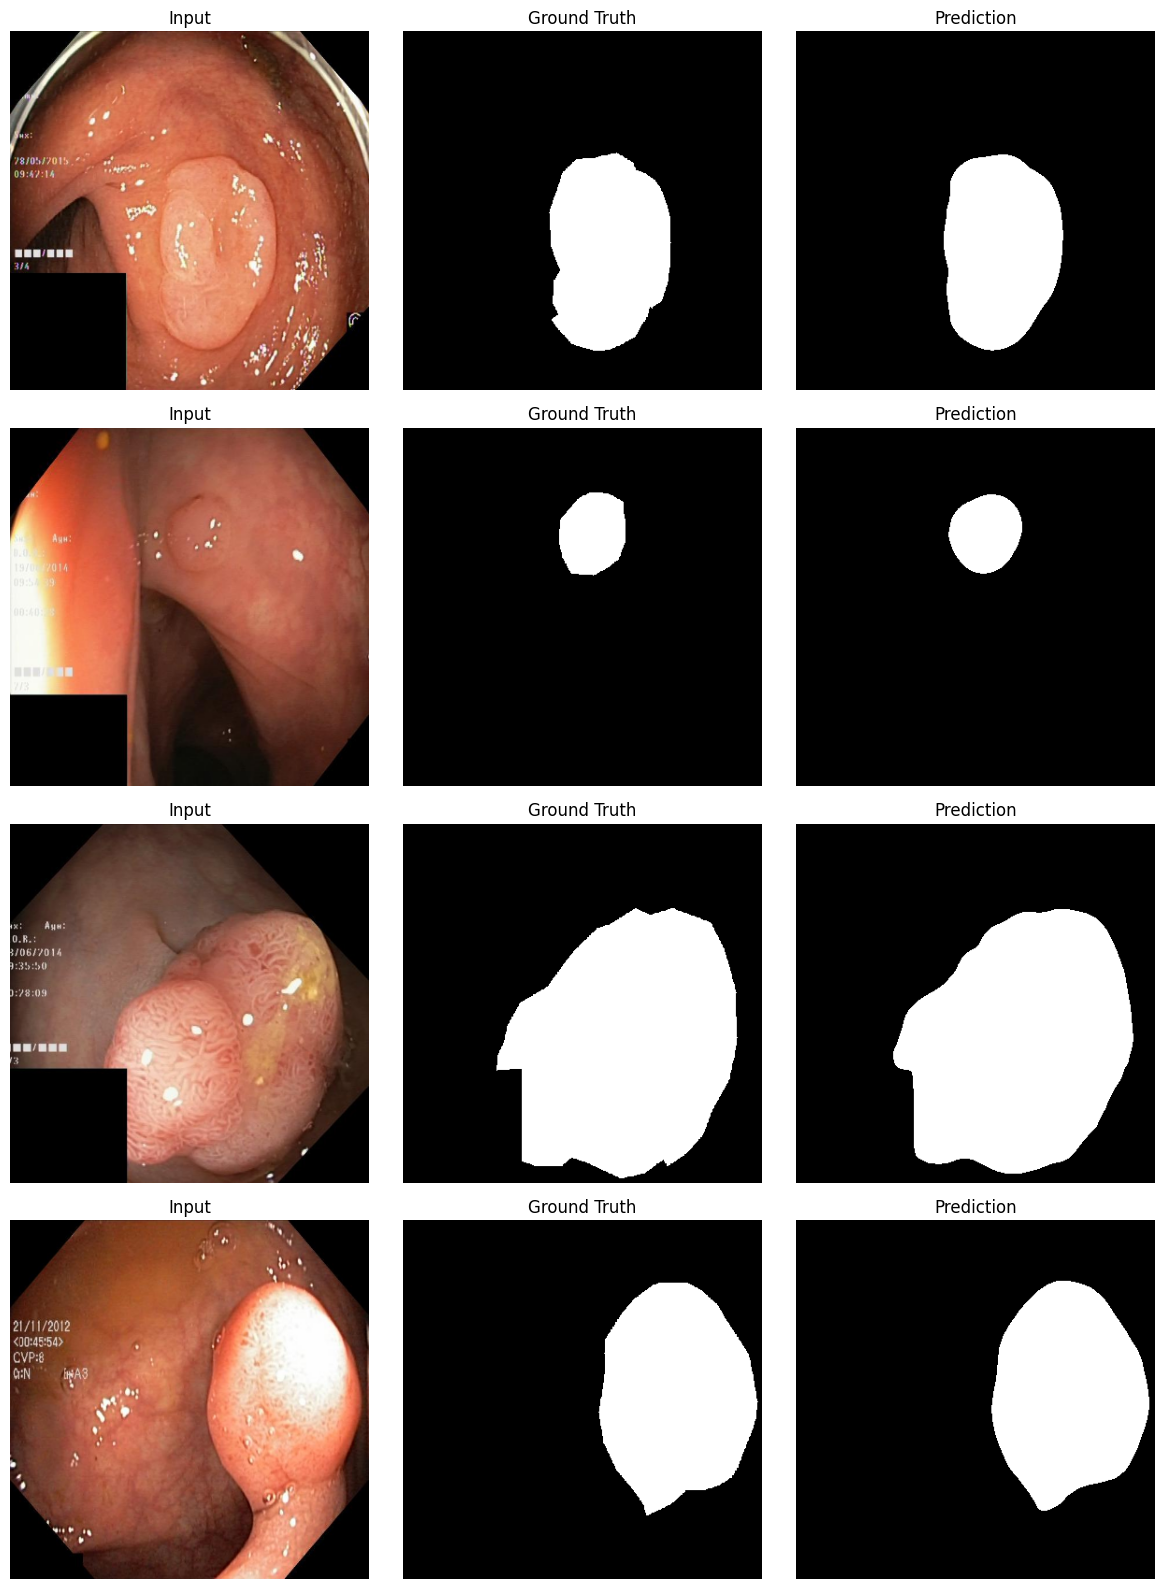

In [27]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
net.load_state_dict(torch.load(os.path.join(checkpoint_dir, "best_model.pth")))

# ===============================================
# Test Evaluation - Orijinal Proje ile Uyumlu
# ===============================================

def full_evaluate(model, dataloader, device):
    """
    Tüm test seti üzerinde değerlendirme yapar.
    Orijinal projedeki metrikleri hesaplar.
    """
    model.eval()

    # Metrik toplama
    total_recall = 0
    total_specificity = 0
    total_precision = 0
    total_F1 = 0
    total_F2 = 0
    total_ACC = 0
    total_IoU_poly = 0
    total_IoU_bg = 0
    total_IoU_mean = 0
    total_dice = 0

    num_samples = 0

    with torch.no_grad():
        bar = tqdm(dataloader, desc="Evaluating on Test Set")
        for batch in bar:
            if isinstance(batch, dict):
                img = batch['image']
                gt = batch['label']
            else:
                img, gt = batch

            # Normalize
            img = img.to(device).float() / 255.0
            gt = gt.to(device).float()

            # Model prediction
            output = model(img)
            pred = output[0]  # Sigmoid uygulanmış

            # Binary prediction
            pred_binary = (pred >= 0.35).float()
            pred_binary_inv = (pred_binary == 0).float()
            gt_binary = (gt >= 0.5).float()
            gt_binary_inv = (gt_binary == 0).float()

            # Batch içindeki her örnek için
            batch_size = img.size(0)
            for i in range(batch_size):
                p = pred_binary[i]
                p_inv = pred_binary_inv[i]
                g = gt_binary[i]
                g_inv = gt_binary_inv[i]

                TP = (p * g).sum()
                FP = (p * g_inv).sum()
                TN = (p_inv * g_inv).sum()
                FN = (p_inv * g).sum()

                # Sıfıra bölme koruması
                eps = 1e-7

                recall = TP / (TP + FN + eps)
                specificity = TN / (TN + FP + eps)
                precision = TP / (TP + FP + eps)

                F1 = 2 * precision * recall / (precision + recall + eps)
                F2 = 5 * precision * recall / (4 * precision + recall + eps)

                ACC = (TP + TN) / (TP + FP + FN + TN + eps)

                IoU_poly = TP / (TP + FP + FN + eps)
                IoU_bg = TN / (TN + FP + FN + eps)
                IoU_mean = (IoU_poly + IoU_bg) / 2.0

                # Dice Score
                dice = (2 * TP) / (2 * TP + FP + FN + eps)

                total_recall += recall.item()
                total_specificity += specificity.item()
                total_precision += precision.item()
                total_F1 += F1.item()
                total_F2 += F2.item()
                total_ACC += ACC.item()
                total_IoU_poly += IoU_poly.item()
                total_IoU_bg += IoU_bg.item()
                total_IoU_mean += IoU_mean.item()
                total_dice += dice.item()

                num_samples += 1

    # Ortalamaları hesapla
    metrics = {
        'Recall': total_recall / num_samples,
        'Specificity': total_specificity / num_samples,
        'Precision': total_precision / num_samples,
        'F1': total_F1 / num_samples,
        'F2': total_F2 / num_samples,
        'Accuracy': total_ACC / num_samples,
        'IoU_Polyp': total_IoU_poly / num_samples,
        'IoU_Background': total_IoU_bg / num_samples,
        'IoU_Mean (mIoU)': total_IoU_mean / num_samples,
        'Dice': total_dice / num_samples
    }

    return metrics


# ===============================================
# Test Loader - batch_size=1 (orijinal projede böyle)
# ===============================================
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.to(device)

# ===============================================
# Evaluate
# ===============================================
print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

metrics = full_evaluate(net, test_loader, device)

print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)
for name, value in metrics.items():
    print(f"{name:20s}: {value:.4f}")
print("=" * 60)

# ===============================================
# Görselleştirme (Birkaç örnek)
# ===============================================
print("\n📊 Sample Predictions:")
net.eval()

# Shuffle True ile yeni loader
vis_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)
batch = next(iter(vis_loader))

if isinstance(batch, dict):
    img = batch['image']
    gt = batch['label']
else:
    img, gt = batch

img = img.to(device).float() / 255.0
gt = gt.to(device).float()

with torch.no_grad():
    output = net(img)
    pred = output[0]
    pred_bin = (pred > 0.5).float()

# 4 örnek göster
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):
    # Input
    axes[i, 0].imshow(img[i].permute(1, 2, 0).cpu())
    axes[i, 0].set_title("Input")
    axes[i, 0].axis("off")

    # GT
    axes[i, 1].imshow(gt[i, 0].cpu(), cmap='gray')
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    # Prediction
    axes[i, 2].imshow(pred_bin[i, 0].cpu(), cmap='gray')
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [28]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# FEATURE MAP VİZUALİZASYON - Hook ile Katman Çıktıları
# ============================================================

class FeatureMapVisualizer:
    def __init__(self, model):
        self.model = model
        self.activations = {}
        self.hooks = []

    def get_activation(self, name):
        """Hook fonksiyonu - katman çıktısını yakalar"""
        def hook(model, input, output):
            self.activations[name] = output.detach()
        return hook

    def register_hooks(self, layer_names):
        """Belirtilen katmanlara hook ekler"""
        self.remove_hooks()  # Önceki hook'ları temizle

        for name in layer_names:
            # Nested katmanlara erişim (örn: "Encoder.enc1_conv")
            parts = name.split('.')
            layer = self.model
            for part in parts:
                layer = getattr(layer, part)

            hook = layer.register_forward_hook(self.get_activation(name))
            self.hooks.append(hook)

        print(f"✓ {len(layer_names)} katmana hook eklendi")

    def remove_hooks(self):
        """Tüm hook'ları kaldırır"""
        for hook in self.hooks:
            hook.remove()
        self.hooks = []
        self.activations = {}

    def visualize_features(self, img_tensor, layer_name, num_features=16, figsize=(16, 8)):
        """Belirli bir katmanın feature map'lerini görselleştirir"""
        if layer_name not in self.activations:
            print(f"❌ '{layer_name}' bulunamadı. Önce register_hooks() ve forward pass yapın.")
            return

        features = self.activations[layer_name]

        # Batch'in ilk elemanını al
        if features.dim() == 4:
            features = features[0]  # [C, H, W]

        num_channels = features.shape[0]
        num_to_show = min(num_features, num_channels)

        # Grid boyutunu hesapla
        cols = 4
        rows = (num_to_show + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=figsize)
        fig.suptitle(f"Feature Maps: {layer_name} ({num_channels} channels, showing {num_to_show})", fontsize=14)

        axes = axes.flatten()

        for i in range(num_to_show):
            feature_map = features[i].cpu().numpy()
            axes[i].imshow(feature_map, cmap='viridis')
            axes[i].set_title(f"Ch {i}", fontsize=8)
            axes[i].axis('off')

        # Boş subplot'ları gizle
        for i in range(num_to_show, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

    def visualize_all_layers(self, show_channels=4):
        """Tüm kayıtlı katmanların özetini gösterir"""
        if not self.activations:
            print("❌ Önce forward pass yapın!")
            return

        num_layers = len(self.activations)
        fig, axes = plt.subplots(num_layers, show_channels + 1, figsize=(16, 3 * num_layers))

        if num_layers == 1:
            axes = axes.reshape(1, -1)

        for idx, (name, features) in enumerate(self.activations.items()):
            if features.dim() == 4:
                features = features[0]

            # İlk sütun: Ortalama aktivasyon
            mean_activation = features.mean(dim=0).cpu().numpy()
            axes[idx, 0].imshow(mean_activation, cmap='hot')
            axes[idx, 0].set_title(f"{name}\nMean ({features.shape})", fontsize=8)
            axes[idx, 0].axis('off')

            # Diğer sütunlar: Birkaç kanal
            for ch in range(min(show_channels, features.shape[0])):
                axes[idx, ch + 1].imshow(features[ch].cpu().numpy(), cmap='viridis')
                axes[idx, ch + 1].set_title(f"Ch {ch}", fontsize=8)
                axes[idx, ch + 1].axis('off')

        plt.tight_layout()
        plt.show()


# ============================================================
# KULLANIM
# ============================================================

# 1. Visualizer oluştur
visualizer = FeatureMapVisualizer(net)

# 2. İzlemek istediğin katmanları belirle
layers_to_watch = [
    # Encoder katmanları
    "Encoder.enc1_conv",
    "Encoder.enc2",
    "Encoder.enc3",
    "Encoder.enc4",
    "Encoder.enc5",
    # Decoder katmanları
    "seg_decoder5",
    "seg_decoder4",
    "seg_decoder3",
    "seg_decoder2",
    "seg_decoder1",
    # GFF modülleri
    "gff5",
    "gff4",
    "gff3",
    "gff2",
    "gff1",
    # Side outputs
    "seg_sideout5",
    "seg_sideout4",
    "seg_sideout3",
    "seg_sideout2",
    "seg_sideout1",
]

# 3. Hook'ları kaydet
visualizer.register_hooks(layers_to_watch)

# 4. Test görüntüsü al
test_batch = next(iter(test_loader))
if isinstance(test_batch, dict):
    test_img = test_batch['image']
    test_gt = test_batch['label']
else:
    test_img, test_gt = test_batch

test_img = test_img.to(device).float() / 255.0

# 5. Forward pass (hook'lar çıktıları yakalar)
net.eval()
with torch.no_grad():
    output = net(test_img)

print(f"\n✓ Forward pass tamamlandı. {len(visualizer.activations)} katman yakalandı.")
print("\nYakalanan katmanlar:")
for name, feat in visualizer.activations.items():
    print(f"  {name}: {feat.shape}")

✓ 20 katmana hook eklendi

✓ Forward pass tamamlandı. 20 katman yakalandı.

Yakalanan katmanlar:
  Encoder.enc1_conv: torch.Size([1, 64, 192, 192])
  Encoder.enc2: torch.Size([1, 64, 96, 96])
  Encoder.enc3: torch.Size([1, 128, 48, 48])
  Encoder.enc4: torch.Size([1, 256, 24, 24])
  Encoder.enc5: torch.Size([1, 512, 12, 12])
  seg_decoder5: torch.Size([1, 512, 24, 24])
  seg_decoder4: torch.Size([1, 256, 48, 48])
  seg_decoder3: torch.Size([1, 128, 96, 96])
  seg_decoder2: torch.Size([1, 64, 192, 192])
  seg_decoder1: torch.Size([1, 64, 384, 384])
  gff5: torch.Size([1, 512, 12, 12])
  gff4: torch.Size([1, 256, 24, 24])
  gff3: torch.Size([1, 128, 48, 48])
  gff2: torch.Size([1, 64, 96, 96])
  gff1: torch.Size([1, 64, 192, 192])
  seg_sideout5: torch.Size([1, 1, 24, 24])
  seg_sideout4: torch.Size([1, 1, 48, 48])
  seg_sideout3: torch.Size([1, 1, 96, 96])
  seg_sideout2: torch.Size([1, 1, 192, 192])
  seg_sideout1: torch.Size([1, 1, 384, 384])


In [29]:
# ============================================
# TÜM ARA DEĞİŞKENLERİ GÖRSELLEŞTIREN DEBUG FORWARD
# ============================================

def debug_forward(model, x, ori):
    """Forward fonksiyonundaki TÜM ara değişkenleri döndürür"""
    intermediates = {}

    # İlk pass - coarse segmentation
    e1, e2, e3, e4, e5 = model.Encoder(x)
    intermediates['e1'] = e1.clone()
    intermediates['e2'] = e2.clone()
    intermediates['e3'] = e3.clone()
    intermediates['e4'] = e4.clone()
    intermediates['e5'] = e5.clone()

    d5 = model.seg_decoder5(e5)
    d4 = model.seg_decoder4(torch.cat([e4, d5], dim=1))
    d3 = model.seg_decoder3(torch.cat([e3, d4], dim=1))
    d2 = model.seg_decoder2(torch.cat([e2, d3], dim=1))
    d1 = model.seg_decoder1(torch.cat([e1, d2], dim=1))

    # İlk pass decoder çıktıları (suffix: _p1 = pass 1)
    intermediates['d5_p1'] = d5.clone()
    intermediates['d4_p1'] = d4.clone()
    intermediates['d3_p1'] = d3.clone()
    intermediates['d2_p1'] = d2.clone()
    intermediates['d1_p1'] = d1.clone()

    mask = model.seg_outconv(d1)
    mask = torch.sigmoid(mask)
    mask_binary = (mask < 0.5).float()
    mask_rbinary = (mask > 0.5).float()

    intermediates['mask'] = mask.clone()
    intermediates['mask_binary'] = mask_binary.clone()
    intermediates['mask_rbinary'] = mask_rbinary.clone()

    # Inpainting için maskelenmiş görüntü
    cut_ori = ori * mask_rbinary
    intermediates['cut_ori'] = cut_ori.clone()

    # İkinci pass - GFF ile birleştirilmiş
    e1, e2, e3, e4, e5 = model.Encoder(ori)
    inpe1, inpe2, inpe3, inpe4, inpe5 = model.Encoder(cut_ori)

    # İkinci pass encoder çıktıları
    intermediates['e1_p2'] = e1.clone()
    intermediates['e2_p2'] = e2.clone()
    intermediates['e3_p2'] = e3.clone()
    intermediates['e4_p2'] = e4.clone()
    intermediates['e5_p2'] = e5.clone()

    # Inpainting encoder çıktıları
    intermediates['inpe1'] = inpe1.clone()
    intermediates['inpe2'] = inpe2.clone()
    intermediates['inpe3'] = inpe3.clone()
    intermediates['inpe4'] = inpe4.clone()
    intermediates['inpe5'] = inpe5.clone()

    # GFF çıktıları
    ge5 = model.gff5(e5, inpe5)
    ge4 = model.gff4(e4, inpe4)
    ge3 = model.gff3(e3, inpe3)
    ge2 = model.gff2(e2, inpe2)
    ge1 = model.gff1(e1, inpe1)

    intermediates['ge1'] = ge1.clone()
    intermediates['ge2'] = ge2.clone()
    intermediates['ge3'] = ge3.clone()
    intermediates['ge4'] = ge4.clone()
    intermediates['ge5'] = ge5.clone()

    # İkinci pass decoder
    d5 = model.seg_decoder5(ge5)
    d4 = model.seg_decoder4(torch.cat([ge4, d5], dim=1))
    d3 = model.seg_decoder3(torch.cat([ge3, d4], dim=1))
    d2 = model.seg_decoder2(torch.cat([ge2, d3], dim=1))
    d1 = model.seg_decoder1(torch.cat([ge1, d2], dim=1))

    # İkinci pass decoder çıktıları (suffix: _p2 = pass 2)
    intermediates['d5_p2'] = d5.clone()
    intermediates['d4_p2'] = d4.clone()
    intermediates['d3_p2'] = d3.clone()
    intermediates['d2_p2'] = d2.clone()
    intermediates['d1_p2'] = d1.clone()

    # Side outputs
    sidemask5 = model.seg_sideout5(d5)
    sidemask4 = model.seg_sideout4(d4)
    sidemask3 = model.seg_sideout3(d3)
    sidemask2 = model.seg_sideout2(d2)
    sidemask1_logit = model.seg_sideout1(d1)
    sidemask1 = torch.sigmoid(sidemask1_logit)

    intermediates['sidemask1'] = sidemask1.clone()
    intermediates['sidemask2'] = sidemask2.clone()
    intermediates['sidemask3'] = sidemask3.clone()
    intermediates['sidemask4'] = sidemask4.clone()
    intermediates['sidemask5'] = sidemask5.clone()

    # Final binary masks
    mask_binary_final = (sidemask1 > 0.5).float()
    mask_rbinary_final = (sidemask1 < 0.5).float()
    intermediates['mask_binary_final'] = mask_binary_final.clone()
    intermediates['mask_rbinary_final'] = mask_rbinary_final.clone()

    # Inpainting decoder
    inp_d5 = model.inp_decoder5(ge5)
    inp_d4 = model.inp_decoder4(torch.cat([ge4, inp_d5], dim=1))
    inp_d3 = model.inp_decoder3(torch.cat([ge3, inp_d4], dim=1))
    inp_d2 = model.inp_decoder2(torch.cat([ge2, inp_d3], dim=1))
    inp_d1 = model.inp_decoder1(torch.cat([ge1, inp_d2], dim=1))

    intermediates['inp_d5'] = inp_d5.clone()
    intermediates['inp_d4'] = inp_d4.clone()
    intermediates['inp_d3'] = inp_d3.clone()
    intermediates['inp_d2'] = inp_d2.clone()
    intermediates['inp_d1'] = inp_d1.clone()

    # Inpainting side outputs
    sideinp5 = model.inp_sideout5(inp_d5)
    sideinp4 = model.inp_sideout4(inp_d4)
    sideinp3 = model.inp_sideout3(inp_d3)
    sideinp2 = model.inp_sideout2(inp_d2)
    sideinp1 = model.inp_sideout1(inp_d1)

    intermediates['sideinp1'] = sideinp1.clone()
    intermediates['sideinp2'] = sideinp2.clone()
    intermediates['sideinp3'] = sideinp3.clone()
    intermediates['sideinp4'] = sideinp4.clone()
    intermediates['sideinp5'] = sideinp5.clone()

    # Final inpainting image
    inpimg = sideinp1 * mask_binary_final + ori * mask_rbinary_final
    intermediates['inpimg'] = inpimg.clone()

    return intermediates

# Test görüntüsü al
net.eval()
with torch.no_grad():
    for batch in test_loader:
        # Dataset "image" ve "label" döndürüyor
        img = batch['image'].to(device).float()
        # Eğer 0-255 aralığındaysa normalize et
        if img.max() > 1.0:
            img = img / 255.0
        mask_gt = batch['label'].to(device).float()
        # ori = img (normalize edilmiş görüntü kullanılıyor)
        ori = img.clone()
        break

    # Debug forward çalıştır
    intermediates = debug_forward(net, img, ori)

print("Toplam ara değişken sayısı:", len(intermediates))
print("\nDeğişkenler ve boyutları:")
for name, tensor in intermediates.items():
    print(f"  {name}: {list(tensor.shape)}")

Toplam ara değişken sayısı: 52

Değişkenler ve boyutları:
  e1: [1, 64, 192, 192]
  e2: [1, 64, 96, 96]
  e3: [1, 128, 48, 48]
  e4: [1, 256, 24, 24]
  e5: [1, 512, 12, 12]
  d5_p1: [1, 512, 24, 24]
  d4_p1: [1, 256, 48, 48]
  d3_p1: [1, 128, 96, 96]
  d2_p1: [1, 64, 192, 192]
  d1_p1: [1, 64, 384, 384]
  mask: [1, 1, 384, 384]
  mask_binary: [1, 1, 384, 384]
  mask_rbinary: [1, 1, 384, 384]
  cut_ori: [1, 3, 384, 384]
  e1_p2: [1, 64, 192, 192]
  e2_p2: [1, 64, 96, 96]
  e3_p2: [1, 128, 48, 48]
  e4_p2: [1, 256, 24, 24]
  e5_p2: [1, 512, 12, 12]
  inpe1: [1, 64, 192, 192]
  inpe2: [1, 64, 96, 96]
  inpe3: [1, 128, 48, 48]
  inpe4: [1, 256, 24, 24]
  inpe5: [1, 512, 12, 12]
  ge1: [1, 64, 192, 192]
  ge2: [1, 64, 96, 96]
  ge3: [1, 128, 48, 48]
  ge4: [1, 256, 24, 24]
  ge5: [1, 512, 12, 12]
  d5_p2: [1, 512, 24, 24]
  d4_p2: [1, 256, 48, 48]
  d3_p2: [1, 128, 96, 96]
  d2_p2: [1, 64, 192, 192]
  d1_p2: [1, 64, 384, 384]
  sidemask1: [1, 1, 384, 384]
  sidemask2: [1, 1, 192, 192]
  sid

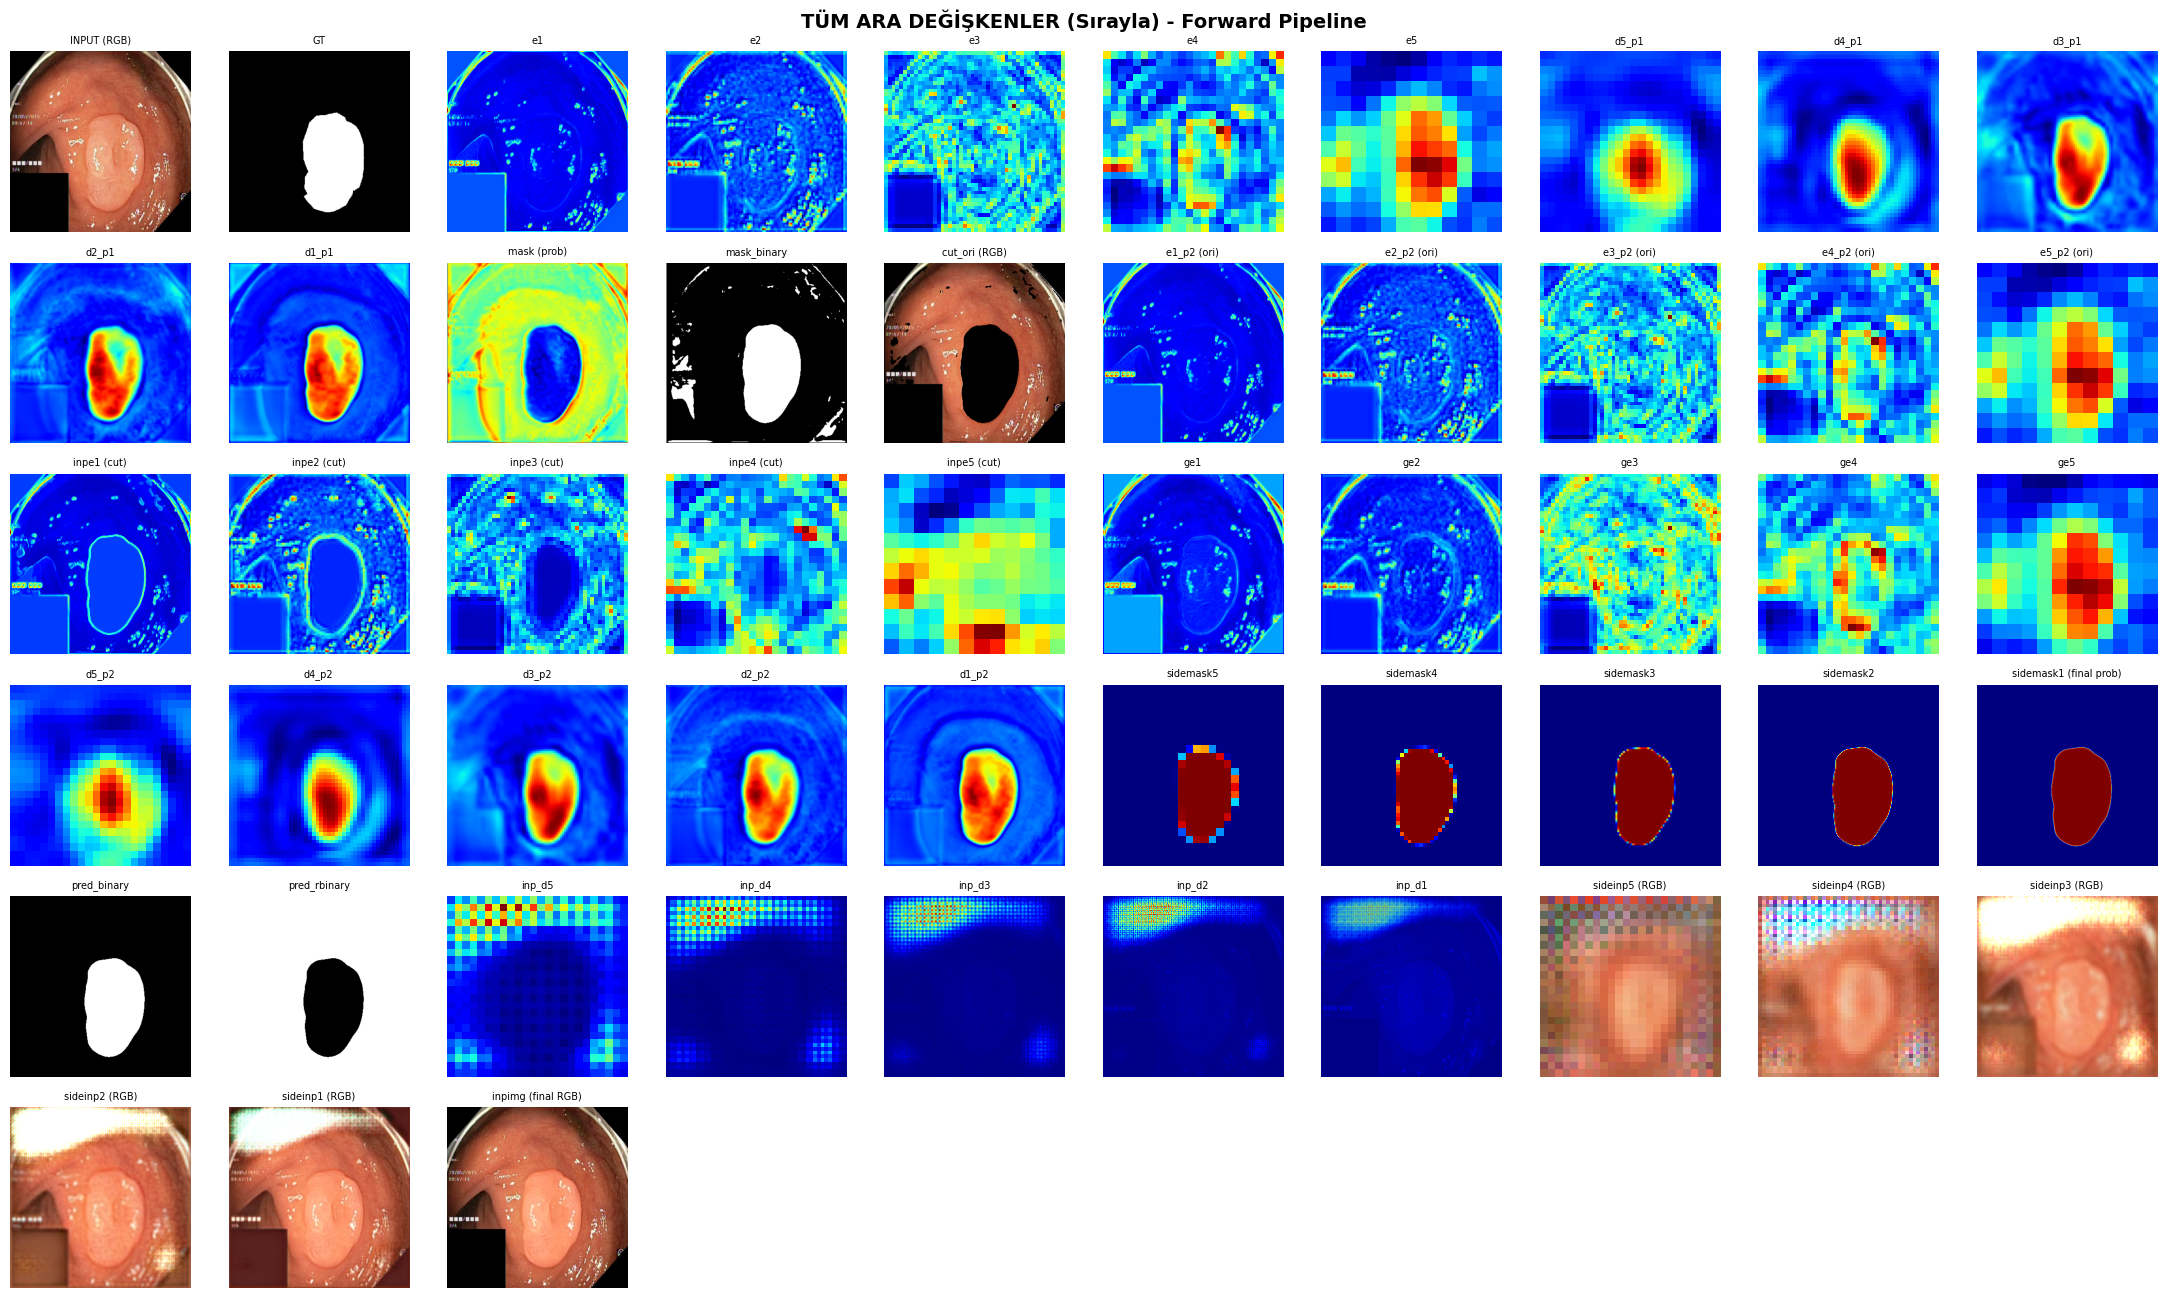


📊 Toplam 53 değişken görselleştirildi.


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ============================================
# SUPERIMPOSED VİZUALİZASYON FONKSİYONU
# ============================================

def visualize_superimposed(tensor, title, ax, cmap='jet'):
    """Tüm kanalların ortalamasını alarak tek görüntü olarak göster"""
    if tensor.dim() == 4:
        tensor = tensor[0]

    if tensor.shape[0] > 1:
        superimposed = tensor.mean(dim=0).cpu().detach().numpy()
    else:
        superimposed = tensor[0].cpu().detach().numpy()

    # Normalize et (Görselin net görünmesi için)
    superimposed = (superimposed - superimposed.min()) / (superimposed.max() - superimposed.min() + 1e-8)

    ax.imshow(superimposed, cmap=cmap)
    ax.set_title(title, fontsize=7)
    ax.axis('off')

def visualize_rgb(tensor, title, ax):
    """3 kanallı RGB görüntü olarak göster"""
    if tensor.dim() == 4:
        tensor = tensor[0]

    rgb = tensor.cpu().detach().numpy().transpose(1, 2, 0)
    rgb = np.clip(rgb, 0, 1)

    ax.imshow(rgb)
    ax.set_title(title, fontsize=7)
    ax.axis('off')

# ============================================
# TÜM DEĞİŞKENLER - RENK AYARLI LİSTE
# ============================================

# Renk Mantığı:
# 'rgb'   -> 3 kanallı renkli resimler
# 'gray'  -> Kesin Maskeler (Binary 0 veya 1)
# 'jet'   -> Feature mapler, olasılık haritaları (Probability maps), ara katmanlar

all_vars = [
    # INPUT
    ('ori', 'INPUT (RGB)', 'rgb'),
    ('mask_gt', 'GT', 'gray'),

    # ENCODER Pass 1 (Features -> JET)
    ('e1', 'e1', 'jet'),
    ('e2', 'e2', 'jet'),
    ('e3', 'e3', 'jet'),
    ('e4', 'e4', 'jet'),
    ('e5', 'e5', 'jet'),

    # DECODER Pass 1 (Features -> JET)
    ('d5_p1', 'd5_p1', 'jet'),
    ('d4_p1', 'd4_p1', 'jet'),
    ('d3_p1', 'd3_p1', 'jet'),
    ('d2_p1', 'd2_p1', 'jet'),
    ('d1_p1', 'd1_p1', 'jet'),

    # COARSE MASK
    ('mask', 'mask (prob)', 'jet'),       # Henüz binary değil, olasılık haritası
    ('mask_binary', 'mask_binary', 'gray'), # Binary
    ('cut_ori', 'cut_ori (RGB)', 'rgb'),

    # ENCODER Pass 2 - ori (Features -> JET)
    ('e1_p2', 'e1_p2 (ori)', 'jet'),
    ('e2_p2', 'e2_p2 (ori)', 'jet'),
    ('e3_p2', 'e3_p2 (ori)', 'jet'),
    ('e4_p2', 'e4_p2 (ori)', 'jet'),
    ('e5_p2', 'e5_p2 (ori)', 'jet'),

    # ENCODER Pass 2 - cut_ori (Features -> JET)
    ('inpe1', 'inpe1 (cut)', 'jet'),
    ('inpe2', 'inpe2 (cut)', 'jet'),
    ('inpe3', 'inpe3 (cut)', 'jet'),
    ('inpe4', 'inpe4 (cut)', 'jet'),
    ('inpe5', 'inpe5 (cut)', 'jet'),

    # GFF (Features -> JET)
    ('ge1', 'ge1', 'jet'),
    ('ge2', 'ge2', 'jet'),
    ('ge3', 'ge3', 'jet'),
    ('ge4', 'ge4', 'jet'),
    ('ge5', 'ge5', 'jet'),

    # DECODER Pass 2 (Features -> JET)
    ('d5_p2', 'd5_p2', 'jet'),
    ('d4_p2', 'd4_p2', 'jet'),
    ('d3_p2', 'd3_p2', 'jet'),
    ('d2_p2', 'd2_p2', 'jet'),
    ('d1_p2', 'd1_p2', 'jet'),

    # SEG SIDE OUTPUTS (Probability Maps -> JET)
    ('sidemask5', 'sidemask5', 'jet'),
    ('sidemask4', 'sidemask4', 'jet'),
    ('sidemask3', 'sidemask3', 'jet'),
    ('sidemask2', 'sidemask2', 'jet'),
    ('sidemask1', 'sidemask1 (final prob)', 'jet'),

    # FINAL MASKS (Binary -> GRAY)
    ('mask_binary_final', 'pred_binary', 'gray'),
    ('mask_rbinary_final', 'pred_rbinary', 'gray'),

    # INPAINTING DECODER (Features -> JET)
    ('inp_d5', 'inp_d5', 'jet'),
    ('inp_d4', 'inp_d4', 'jet'),
    ('inp_d3', 'inp_d3', 'jet'),
    ('inp_d2', 'inp_d2', 'jet'),
    ('inp_d1', 'inp_d1', 'jet'),

    # INPAINTING SIDE OUTPUTS (RGB -> RGB)
    ('sideinp5', 'sideinp5 (RGB)', 'rgb'),
    ('sideinp4', 'sideinp4 (RGB)', 'rgb'),
    ('sideinp3', 'sideinp3 (RGB)', 'rgb'),
    ('sideinp2', 'sideinp2 (RGB)', 'rgb'),
    ('sideinp1', 'sideinp1 (RGB)', 'rgb'),

    # FINAL INPAINTING (RGB -> RGB)
    ('inpimg', 'inpimg (final RGB)', 'rgb'),
]

# ============================================
# ÇİZDİRME DÖNGÜSÜ
# ============================================

# Grid boyutu hesapla
n_vars = len(all_vars)
n_cols = 10
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 2.2))
axes = axes.flatten()

for i, (var_name, title, cmap) in enumerate(all_vars):
    # Değişken sözlükte var mı kontrolü (Hata almamak için)
    if var_name == 'ori':
        visualize_rgb(ori, title, axes[i])
    elif var_name == 'mask_gt':
        visualize_superimposed(mask_gt, title, axes[i], cmap)
    # intermediates sözlüğünden veriyi çekiyoruz (senin kod yapına göre burayı düzenle)
    elif var_name in intermediates:
        if cmap == 'rgb':
            visualize_rgb(intermediates[var_name], title, axes[i])
        else:
            visualize_superimposed(intermediates[var_name], title, axes[i], cmap)
    else:
        # Eğer değişken bulunamazsa boş geç
        axes[i].text(0.5, 0.5, 'Not Found', ha='center')
        axes[i].axis('off')

# Boş hücreleri kapat
for i in range(n_vars, len(axes)):
    axes[i].axis('off')

plt.suptitle('TÜM ARA DEĞİŞKENLER (Sırayla) - Forward Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Toplam {n_vars} değişken görselleştirildi.")